In [1]:
import os, time, json
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from joblib import Parallel, delayed
from sb3_contrib import MaskablePPO
from backward_map_core import *

N_JOBS = 12
MODELS = {
    "agent, single-query (50,20)": ("runs10-6/single_z50-20_lam1_R3K3/seed1/checkpoints/ppo_final.zip", MapEnv),
    "agent, t*-sweep":             ("runs10-7/multi15_gae098_n1024_lam1_R3K3/seed1/checkpoints/ppo_final.zip", MapEnvGen),
}
agents = {name: (MaskablePPO.load(path, device="cpu"), cls) for name, (path, cls) in MODELS.items()}

# ── Check: every method at z* = (50, 20) ──
z = (50, 20)
for name, mm in [("LW", build_map(z, lw)), ("lowest score", build_map(z, lowest_score)),
                 ("greedy (lam=1)", build_map(z, greedy_at(1.0))), ("best fixed (50,20)", build_map(z, fixed_rule(BEST_FIXED_50_20)))]:
    rep = report(mm)
    print(f"{name:28s}: {rep['points']:4d} points | work {rep['work']:5d} | error {rep['error']:.1e} | bound {rep['bound']:.1e} | return {map_return(mm, z, 1.0):6.2f}")
for name, (mdl, cls) in agents.items():
    e = run_policy(mdl, z, 1.0, cls); rep = report(e.m)
    print(f"{name:28s}: {rep['points']:4d} points | work {rep['work']:5d} | error {rep['error']:.1e} | bound {rep['bound']:.1e} | return {map_return(e.m, z, 1.0):6.2f}")

LW                          :  400 points | work  1200 | error 3.0e-05 | bound 3.0e-05 | return  -2.00
lowest score                :  670 points | work  3350 | error 1.5e-07 | bound 1.6e-07 | return  -1.69
greedy (lam=1)              :  313 points | work  1565 | error 1.3e-07 | bound 4.6e-06 | return  -0.96
best fixed (50,20)          :  168 points | work   840 | error 8.4e-07 | bound 1.1e-06 | return  -0.50
agent, single-query (50,20) :  323 points | work  1615 | error 8.2e-08 | bound 4.2e-06 | return  -1.08
agent, t*-sweep             :  503 points | work  2515 | error 6.0e-06 | bound 6.7e-06 | return  -1.81


### Test set: 20 initial conditions
The maps are built without the initial condition (the agent and the rules see geometry only), so the same map can be tested on any IC. Measuring each method on many ICs instead of one avoids lucky cancellations at a single point.
IC 0 is the training IC; the other 19 are random: $u_0=\sum_{n=1}^{4}a_n\sin(n\pi x)$ with $a_n\sim\mathcal N(0,1/n^2)$, scaled to $\max|u_0|=1$.

20 initial conditions (IC 0 = training IC), exact solutions built in 18 s
max |u_true - u0| at t = 0 over all ICs: 4.5e-07


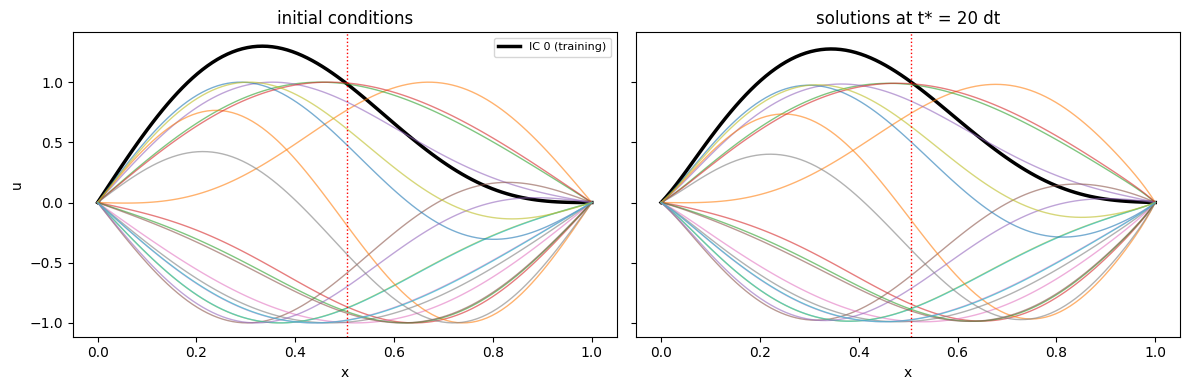

In [5]:
# ── Test set: random initial conditions (the maps are built without the IC, so they can be tested on any IC) ──
N_IC, N_MODES = 20, 2
rng = np.random.default_rng(0)
def random_ic(rng):
    """u0 = sum_n a_n sin(n pi x), n = 1..N_MODES, a_n ~ N(0, 1/n^2), scaled to max|u0| = 1."""
    an = rng.normal(0, 1 / np.arange(1, N_MODES + 1))
    raw = lambda x: sum(a_ * np.sin((n + 1) * np.pi * np.asarray(x, dtype=float)) for n, a_ in enumerate(an))
    s = np.abs(raw(np.linspace(0, 1, 2001))).max()
    return lambda x: raw(x) / s

t0 = time.time()
IC_FNS = [u0] + [random_ic(rng) for _ in range(N_IC - 1)]          # IC 0 = the training IC
U_FNS  = [make_u_true(ic) for ic in IC_FNS]
print(f"{N_IC} initial conditions (IC 0 = training IC), exact solutions built in {time.time() - t0:.0f} s")
print("max |u_true - u0| at t = 0 over all ICs:", f"{max(np.abs(U(x_grid, 0.0) - ic(x_grid)).max() for U, ic in zip(U_FNS, IC_FNS)):.1e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, U in enumerate(U_FNS):
    kw = dict(color="k", lw=2.5, label="IC 0 (training)") if i == 0 else dict(color=f"C{i % 10}", lw=1, alpha=0.6)
    axes[0].plot(x_grid, U(x_grid, 0.0), **kw)
    axes[1].plot(x_grid, U(x_grid, 20 * dt), **kw)
axes[0].set_title("initial conditions"); axes[1].set_title("solutions at t* = 20 dt")
for ax in axes: ax.set_xlabel("x"); ax.axvline(50 * dx, color="r", ls=":", lw=1)
axes[0].set_ylabel("u"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Maps for z* = (50, 20)
Every method builds its map once (the maps don't depend on the IC):
- **LW** and **lowest score**: one map each;
- **greedy** and **best fixed stencil**: one map per price of a point $\lambda\in\{0.1,0.3,1,3,10\}$, giving a curve from accurate (small $\lambda$) to cheap (large $\lambda$). The best fixed stencil for each $\lambda$ comes from one brute force over all 18,694 stencils;
- **the single-query agent**: one map (trained at $\lambda=1$).

In [6]:
# ── All maps for z* = (50, 20), built once (they don't depend on the IC) ──
Z    = (50, 20)
LAMS = [0.1, 0.3, 1, 3, 10]

def bf_chunk(stencils, z):  
    """Score sum and points of the map that uses each stencil everywhere it is admissible."""
    out = []
    for s in stencils:
        mm = build_map(z, fixed_rule(s))
        out.append((s, sum(abs(mm["beta"][p]) * point_score(p, *mm["stencil"][p]) for p in mm["stencil"]), len(mm["stencil"])))
    return out

t0 = time.time()
interior = admissible(Z)[0]
bf = [r for part in Parallel(n_jobs=N_JOBS)(delayed(bf_chunk)([interior[i] for i in idx], Z)
                                            for idx in np.array_split(np.arange(len(interior)), N_JOBS)) for r in part]
B_ref, N_ref = reference(Z)
best_fixed = {lam: max(bf, key=lambda r: -r[1] / B_ref - lam * (r[2] - 1) / N_ref)[0] for lam in LAMS}
print(f"brute force over {len(bf)} fixed stencils: {time.time() - t0:.0f} s")

MAPS = {"LW": [build_map(Z, lw)],
        "lowest score": [build_map(Z, lowest_score)],
        "greedy": [build_map(Z, greedy_at(lam)) for lam in LAMS],
        "best fixed": [build_map(Z, fixed_rule(best_fixed[lam])) for lam in LAMS]}
mdl, cls = agents["agent, single-query (50,20)"]
MAPS["agent, single-query (50,20)"] = [run_policy(mdl, Z, 1.0, cls).m]

print(f"\n{'method':28s} {'lam':>5s} {'points':>7s} {'work':>6s}   stencil (fixed only)")
for name, maps in MAPS.items():
    lams = LAMS if len(maps) == len(LAMS) else [1.0 if "agent" in name else None]
    for lam, mm in zip(lams, maps):
        extra = [WINDOW[k] for k in best_fixed[lam]] if name == "best fixed" else ""
        print(f"{name:28s} {'' if lam is None else lam:>5} {len(mm['stencil']):7d} "
              f"{sum(len(nbs) for nbs, _ in mm['stencil'].values()):6d}   {extra}")

brute force over 18694 fixed stencils: 40 s

method                         lam  points   work   stencil (fixed only)
LW                                     400   1200   
lowest score                           670   3350   
greedy                         0.1     424   2120   
greedy                         0.3     372   1860   
greedy                           1     313   1565   
greedy                           3     298   1490   
greedy                          10     272   1360   
best fixed                     0.1     334   1670   [(1, -1), (-2, -2), (-3, -3), (0, -3), (3, -3)]
best fixed                     0.3     168    840   [(-1, -1), (-2, -2), (1, -2), (0, -3), (3, -3)]
best fixed                       1     168    840   [(-1, -1), (-2, -2), (1, -2), (0, -3), (3, -3)]
best fixed                       3     162    810   [(-3, -3), (-1, -3), (0, -3), (1, -3), (3, -3)]
best fixed                      10     142    710   [(-3, -3), (-2, -3), (-1, -3), (0, -3), (2, -3)]
agent, sin

### Single query: error vs work over 20 initial conditions
Every map (cell 3) and every classical scheme (grid refined 1–4×) is evaluated on all 20 ICs. Points: median over the ICs; bars: 25%–75%.
Left: true error at $z^*$ (what you actually get). Right: exact bound $\sum|\beta\delta|$ (map methods only).

evaluated on 20 ICs in 2 s

method                          work |  true error: median [25%, 75%] | bound: median | IC 0 error
LW                              1200 |   1.7e-05 [5.0e-06, 3.1e-05] |       1.7e-05 | 3.0e-05
lowest score                    3350 |   1.2e-07 [4.5e-08, 1.7e-07] |       1.2e-07 | 1.5e-07
greedy                          2120 |   5.3e-07 [1.8e-07, 9.6e-07] |       8.1e-07 | 9.5e-07
greedy                          1860 |   9.9e-08 [4.8e-08, 1.6e-07] |       1.1e-06 | 9.8e-08
greedy                          1565 |   1.9e-07 [1.3e-07, 2.1e-07] |       2.5e-06 | 1.3e-07
greedy                          1490 |   1.2e-06 [6.6e-07, 2.1e-06] |       5.5e-06 | 2.2e-06
greedy                          1360 |   1.3e-06 [8.7e-07, 2.3e-06] |       1.4e-05 | 2.5e-06
best fixed                      1670 |   2.1e-07 [1.4e-07, 3.5e-07] |       2.3e-07 | 4.0e-07
best fixed                       840 |   4.9e-07 [3.5e-07, 7.0e-07] |       5.6e-07 | 8.4e-07
best fixed                 

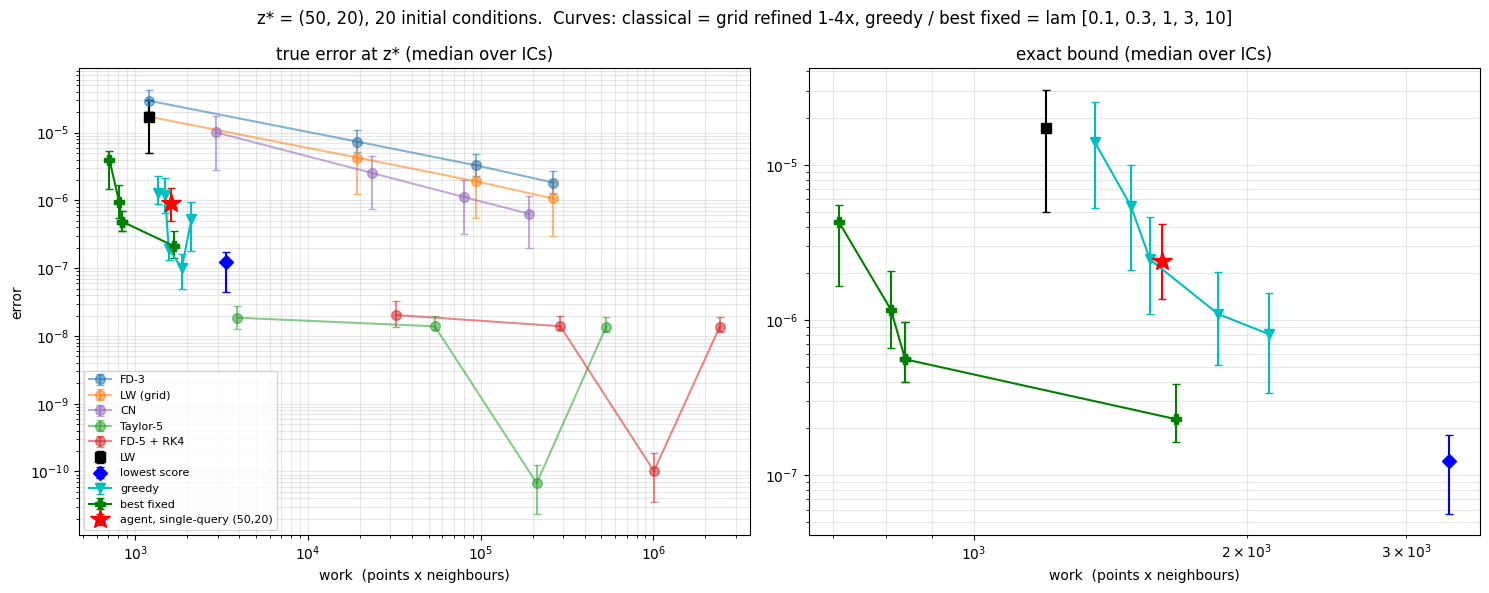

In [7]:
# ── Evaluate every map and every classical scheme on all ICs ──
# Exact values on the whole grid up to t*, once per IC; every map is then checked by lookup (fast).
import warnings; warnings.filterwarnings("ignore", "All-NaN")
FIELDS = [np.array([U(x_grid, it * dt) for it in range(Z[1] + 1)]) for U in U_FNS]     # FIELDS[i][it, ix]

def eval_map(mm, F):
    """(true error at z*, exact bound) of map mm for the IC whose exact field is F."""
    val = lambda q: F[q[1], q[0]] if q[1] == 0 else (0.0 if q[0] in (0, nx - 1) else u_hat[q])
    u_hat = {}
    for p in sorted(mm["stencil"], key=lambda p: p[1]):
        nbs, w = mm["stencil"][p]
        u_hat[p] = sum(wq * val(q) for q, wq in zip(nbs, w))
    bound = sum(abs(mm["beta"][p] * (F[p[1], p[0]] - sum(wq * F[q[1], q[0]] for q, wq in zip(nbs, w))))
                for p, (nbs, w) in mm["stencil"].items())
    return abs(u_hat[mm["z_star"]] - F[Z[1], Z[0]]), bound

t0 = time.time()
RES = {}                                           # name -> list over the curve of (work, errors[N_IC], bounds[N_IC])
for name, maps in MAPS.items():
    RES[name] = []
    for mm in maps:
        eb = np.array([eval_map(mm, F) for F in FIELDS])
        RES[name].append((sum(len(nbs) for nbs, _ in mm["stencil"].values()), eb[:, 0], eb[:, 1]))
for s in ["FD-3", "LW (grid)", "CN", "Taylor-5", "FD-5 + RK4"]:
    scheme = "LW" if s == "LW (grid)" else s
    RES[s] = []
    for k in (1, 2, 3, 4):
        we = [classical(scheme, k, Z, U) for U in U_FNS]
        RES[s].append((we[0][0], np.array([e for _, e in we]), np.full(N_IC, np.nan)))
print(f"evaluated on {N_IC} ICs in {time.time() - t0:.0f} s\n")

q = lambda v: np.nanpercentile(v, [25, 50, 75])
print(f"{'method':28s} {'work':>7s} | {'true error: median [25%, 75%]':>30s} | {'bound: median':>13s} | IC 0 error")
for name, curve in RES.items():
    for work, err, bd in curve:
        lo, med, hi = q(err)
        print(f"{name:28s} {work:7d} | {med:9.1e} [{lo:7.1e}, {hi:7.1e}] | {np.nanmedian(bd) if not np.isnan(bd).all() else np.nan:13.1e} | {err[0]:.1e}")

# ── Picture: median over the ICs (bars: 25%-75%), left = true error, right = exact bound ──
style = {"FD-3": ("o-", "C0"), "LW (grid)": ("o-", "C1"), "CN": ("o-", "C4"), "Taylor-5": ("o-", "C2"), "FD-5 + RK4": ("o-", "C3"),
         "LW": ("s", "k"), "lowest score": ("D", "b"), "greedy": ("v-", "c"), "best fixed": ("P-", "g"),
         "agent, single-query (50,20)": ("*", "r")}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for col, (ax, title) in enumerate(zip(axes, ["true error at z* (median over ICs)", "exact bound (median over ICs)"])):
    for name, (mk, colr) in style.items():
        W = np.array([w for w, _, _ in RES[name]], dtype=float)
        V = np.array([q(e if col == 0 else b) for _, e, b in RES[name]])
        if np.isnan(V[:, 1]).all():
            continue
        classical_line = name in ("FD-3", "LW (grid)", "CN", "Taylor-5", "FD-5 + RK4")
        ax.errorbar(W, V[:, 1], yerr=[V[:, 1] - V[:, 0], V[:, 2] - V[:, 1]], fmt=mk, color=colr, capsize=3,
                    ms=15 if "agent" in name else 7, alpha=0.55 if classical_line else 1, label=name)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel("work  (points x neighbours)"); ax.set_title(title)
axes[0].set_ylabel("error"); axes[0].legend(fontsize=8)
fig.suptitle(f"z* = {Z}, {N_IC} initial conditions.  Curves: classical = grid refined 1-4x, greedy / best fixed = lam {LAMS}")
plt.tight_layout(); plt.show()